In [1]:
%env CUDA_MPS_PIPE_DIRECTORY=/tmp/nvidia-mps-gpu1

env: CUDA_MPS_PIPE_DIRECTORY=/tmp/nvidia-mps-gpu1


# Begin

In [2]:
# @launchit.collected
# @launchit.collected_temp_config
# @launchit.collected_optuna
# @launchit.collected_initrd
# @launchit.collected_build_docker_launch

In [3]:
# @launchit.collected_manual_run_docker_launch
# @launchit.collected_optuna_run_docker_launch

In [4]:
import os # @launchit.collect
import sys # @launchit.collect
import socket
import copy
from collections import namedtuple, defaultdict, Counter, deque # @launchit.collect
import random
import math
import datetime
import json # @launchit.collect
import pprint # @launchit.collect
import re 
import dataclasses # @launchit.collect
from dataclasses import dataclass # @launchit.collect
import pickle # @launchit.collect
import IPython 
from enum import StrEnum, auto # @launchit.collect
import multiprocessing as mp
import queue
import gzip

import lark # @launchit.collect

from tqdm.notebook import tqdm

import numpy as np # @launchit.collect
import cupy as cp
import einops
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as VF
import torch.optim
import torch.multiprocessing as torch_mp
from torch.nn.attention import SDPBackend, sdpa_kernel

import gymnasium as gym 
import ale_py

import optuna # @launchit.collect
from optuna.storages import JournalStorage # @launchit.collect
from optuna.storages.journal import JournalFileBackend # @launchit.collect
from optuna.trial import TrialState

project_root_path = '${PROJECT_ROOT_PATH}' # @launchit.collect
build_project_root_path = '${BUILD_PROJECT_ROOT_PATH}' # @launchit.collect
# @launchit.disable
project_root_path = ! git rev-parse --show-toplevel
project_root_path = project_root_path[0]
# @launchit.stop

sys.path.append(os.path.join(project_root_path, 'lib')) # @launchit.collect
sys.path.append(os.path.join(build_project_root_path, 'lib')) # @launchit.collect
from cleanrl.cleanrl_utils.atari_wrappers import (  # isort:skip
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)
import lang_utils as lu # @launchit.collect
import array_utils as au # @launchit.collect
from math_utils import RecursiveAverageFilter, RecursiveMovingAverageFilter
from logging_utils import *
from artifact_registry import * # @launchit.collect
from torch_utils import *
import launchit 
from hp_utils import * # @launchit.collect
from metrics_collector import RmqSummaryWriter, S3SummaryWriter
from autoincrement import Autoincrement

# Init

In [5]:
# @launchit.collect
class ExecMode(StrEnum):
    MASTER_NOTEBOOK = auto()
    LAUNCH_NOTEBOOK = auto()
    DOCKER_LAUNCH_NOTEBOOK = auto()
    LAUNCH_MODULE = auto()

In [6]:
# @launchit.collect_temp_config
# @launchit.disable

# Construct temporary CONFIG object for build and bootstrap purposes
if '${LAUNCHIT_FNAME}' != '$' + '{LAUNCHIT_FNAME}':
    notebook_fname = '${LAUNCHIT_FNAME}'
    notebook_basename = os.path.basename(notebook_fname)
    notebook_name, notebook_ext = os.path.splitext(notebook_basename)
    subproject_name = os.path.basename(os.path.dirname(notebook_fname))
    
    if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
        # This (bootstrap) config is for the very initial phase of docker launch when one needs to load hyperparameters.
        # This config will be recreated soon to full-fledged Config
        CONFIG = namedtuple('BootstrapConfig', 'initrd_path, exec_mode')(
            initrd_path=os.path.join(project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK,
        )
        assert Logging._instance is None, 'Must create Logging instance with use_raw_stdout=True, but Logging instance is already created'
        # use_raw_stdout is necessary because sys.stdout is hijacked by papermill and this will lead to problems
        # with string duplications written to stdout by child process (worker)
        # see https://share.google/aimode/ffIcoqyaJdgMsEcoW
        Logging.get(use_raw_stdout=True)    
    else:
        # Config to build docker launch
        CONFIG = namedtuple('BuildConfig', 
                            'initrd_path, relative_initrd_path, relative_run_path, relative_metrics_suite_fname, ' + 
                            'model_group_uri, self_fname, relative_self_fname, self_name, subproject_name, ' + 
                            'docker_registry, exec_mode, ' +
                            'artifact_registry_cache, artifact_registry')(
            initrd_path=os.path.join(build_project_root_path, 'run', subproject_name, 'initrd-' + notebook_name),
            relative_initrd_path=os.path.join('run', subproject_name, 'initrd-' + notebook_name), # relative to build project root
            relative_run_path=os.path.join('run', subproject_name),
            relative_metrics_suite_fname=os.path.join('run', subproject_name, notebook_name + '.metrics_suite.json'),
            model_group_uri='${MODEL_GROUP_URI}',
            self_fname=notebook_fname,
            relative_self_fname=lu.when('/run/' in notebook_fname, 'run/', '') + os.path.join(subproject_name, notebook_basename),  # relative to build project root
            self_name=notebook_name,
            subproject_name=subproject_name,
            docker_registry='cr.selcloud.ru/neurolab',
            exec_mode=ExecMode.LAUNCH_NOTEBOOK,
            artifact_registry_cache={}, 
            artifact_registry=None,
        )
        CONFIG = CONFIG._replace(artifact_registry=ArtifactRegistry(CONFIG.model_group_uri, cache=CONFIG.artifact_registry_cache))
        os.makedirs(CONFIG.initrd_path, exist_ok=True)

    Logging.get()(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n')
# @launchit.stop

In [7]:
def create_config():
    config = namedtuple('Config', 
                        'host_name, ' +
                        'project_root_path, project_root_uri, model_group_uri, subproject_path, data_path, private_data_path, run_path, initrd_path, ' + 
                        'self_fname, self_name, metrics_suite_fname, ' +
                        'subproject_name,' +
                        'is_cuda, cuda_device, docker_registry, exec_mode, is_interactive')(
        host_name=socket.gethostname(),
        project_root_path=project_root_path,
        project_root_uri=f'com.develorium.{os.path.basename(project_root_path)}',
        model_group_uri=None,
        subproject_path=os.path.abspath('.'),
        data_path=os.path.join(project_root_path, 'data'),
        private_data_path=None,
        run_path=None,
        initrd_path=None,
        self_fname=None,
        self_name=None,
        metrics_suite_fname=None,
        subproject_name=None,
        is_cuda=torch.cuda.is_available(),
        cuda_device='cpu',
        docker_registry='cr.selcloud.ru/neurolab',
        exec_mode=ExecMode.MASTER_NOTEBOOK,
        is_interactive=True,
    )

    env_cuda_device = os.environ.get('CUDA_DEVICE')
    
    if torch.cuda.is_available():
        default_cuda_device = 'cuda'
        config = config._replace(cuda_device=lu.coalesce(env_cuda_device, default_cuda_device))
    else:
        assert env_cuda_device is None, f'CUDA device "{env_cuda_device}" is requested but CUDA is NOT available!'
    
    if IPython.get_ipython() is None:
        module_fname = __file__
        module_basename = os.path.basename(module_fname)
        module_name, _ = os.path.splitext(module_basename)
        
        config = config._replace(self_fname=module_fname, self_name=module_name)
        config = config._replace(exec_mode=ExecMode.LAUNCH_MODULE)
    else:
        with open(IPython.get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
            notebook_fname = json.load(cf).get('jupyter_session')

            if notebook_fname is None:
                notebook_fname = os.path.join(config.subproject_path, os.path.basename('${LAUNCHIT_FNAME}'))
                assert os.path.exists(notebook_fname)
            
            notebook_basename = os.path.basename(notebook_fname)
            notebook_name, notebook_ext = os.path.splitext(notebook_basename)
        
            m = re.match(r'(\w+)-Copy\d+$', notebook_name)
        
            if m: notebook_name = m.group(1) # e.g. Cuml is used to be launched from the copy of the notebook
    
            config = config._replace(self_fname=notebook_fname, self_name=notebook_name)
            
            is_launch = re.match(r'\w+-launch\d+$', notebook_name) is not None

            if is_launch:
                if os.path.exists(os.path.join(project_root_path, '.docker_launch')):
                    config = config._replace(exec_mode=ExecMode.DOCKER_LAUNCH_NOTEBOOK)
                else:
                    config = config._replace(exec_mode=ExecMode.LAUNCH_NOTEBOOK)
            else:
                assert config.exec_mode == ExecMode.MASTER_NOTEBOOK
    
    config = config._replace(is_interactive=config.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
    config = config._replace(subproject_name=os.path.basename(os.path.dirname(config.self_fname)))
    config = config._replace(model_group_uri=f'{config.project_root_uri}.{config.subproject_name}')
    config = config._replace(run_path=os.path.join(project_root_path, 'run', config.subproject_name))
    config = config._replace(initrd_path=os.path.join(project_root_path, 'run', config.subproject_name, 'initrd-' + config.self_name))
    config = config._replace(private_data_path=os.path.join(config.data_path, config.subproject_name))
    config = config._replace(metrics_suite_fname=os.path.join(config.run_path, config.self_name + '.metrics_suite.json'))
    return config

In [8]:
# @launchit.disable_worker
au.init()
LOG = Logging.get()
RNG = np.random.default_rng()
CONFIG = create_config()
LOG.app_name = CONFIG.self_name
LOG.enable('syslog', CONFIG.exec_mode == ExecMode.LAUNCH_MODULE)
LOG.enable('stdout', CONFIG.exec_mode in [ExecMode.MASTER_NOTEBOOK, ExecMode.LAUNCH_NOTEBOOK])
LOG.enable('verbose_stdout', CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK)
LOG(f'CONFIG=\n{pprint.pformat(CONFIG._asdict(), sort_dicts=False)}\n', when=CONFIG.is_interactive)
LOG(f'CONFIG={CONFIG._asdict()}', when=not CONFIG.is_interactive)
LOG(f'{os.environ=}', when=not CONFIG.is_interactive)
os.makedirs(CONFIG.private_data_path, exist_ok=True)
os.makedirs(CONFIG.run_path, exist_ok=True)
os.makedirs(CONFIG.initrd_path, exist_ok=True)

CONFIG=
{'host_name': 'baki',
 'project_root_path': '/home/misha/dev/mine/neurolab',
 'project_root_uri': 'com.develorium.neurolab',
 'model_group_uri': 'com.develorium.neurolab.18_rl',
 'subproject_path': '/home/misha/dev/mine/neurolab/18_rl',
 'data_path': '/home/misha/dev/mine/neurolab/data',
 'private_data_path': '/home/misha/dev/mine/neurolab/data/18_rl',
 'run_path': '/home/misha/dev/mine/neurolab/run/18_rl',
 'initrd_path': '/home/misha/dev/mine/neurolab/run/18_rl/initrd-18b_dataset_01',
 'self_fname': '/home/misha/dev/mine/neurolab/18_rl/18b_dataset_01.ipynb',
 'self_name': '18b_dataset_01',
 'metrics_suite_fname': '/home/misha/dev/mine/neurolab/run/18_rl/18b_dataset_01.metrics_suite.json',
 'subproject_name': '18_rl',
 'is_cuda': True,
 'cuda_device': 'cuda',
 'docker_registry': 'cr.selcloud.ru/neurolab',
 'exec_mode': <ExecMode.MASTER_NOTEBOOK: 'master_notebook'>,
 'is_interactive': True}



# Hyperparameters

In [9]:
# @launchit.disable
# @launchit.collect
class LaunchGoal(StrEnum):
    UNSPECIFIED = auto()
    TRAIN = auto()
    WORKER = auto()

LaunchComponent = namedtuple('LaunchComponent', 'name version uri main_asset_fname')
    
@dataclass(slots=True)
class Hyperparameters:
    # Launch
    launch_goal: LaunchGoal = lu.from_str(LaunchGoal, '${LAUNCH_GOAL}', LaunchGoal.UNSPECIFIED)
    launch_id: int = lu.from_str(int, '${MODEL_VERSION}', 0)

    @dataclass(slots=True)
    class System:
        comment: str = None
        random_seed: int = None
        is_torch_deterministic: bool = True
        is_torch_compile: bool = False

    @dataclass(slots=True)
    class Dataset:
        ob_shape: tuple = (1, 178, 152)
        sequence_length: int = 5

    @dataclass(slots=True)
    class Rollout:
        steps_count: int = 512 
        envs_count: int = 32
        env_is_max_pooling: bool = True
        env_rams: list = None
        env_ram_patches: list = None
        env_stories: list = dataclasses.field(default_factory=lambda: ['*;*']) # story = RAM + RAM patch. '*' = any RAM/RAM patch

    system: System = dataclasses.field(default_factory=System)
    agents: list = None 
    dataset: Dataset = dataclasses.field(default_factory=Dataset)
    rollout: Rollout = dataclasses.field(default_factory=Rollout)

    @staticmethod
    def from_dict(d):
        hp = Hyperparameters(**d)
        hp.system = Hyperparameters.System(**hp.system)
        hp.agents = hp.agents
        hp.dataset = Hyperparameters.Agent(**hp.dataset)
        hp.rollout = Hyperparameters.Env(**hp.rollout)
        return hp

    def _asdict(self):
        return dataclasses.asdict(self)

    def launch_component(self):
        name = lu.when('${MODEL_NAME}' == '$' + '{MODEL_NAME}', CONFIG.self_name, '${MODEL_NAME}')
        return LaunchComponent(name=name, version=self.launch_id,  uri=f'{CONFIG.model_group_uri}.{name}', main_asset_fname=CONFIG.self_fname)

HP = Hyperparameters()

# Runtime

## Runtime

In [10]:
@dataclass(slots=True)
class Runtime:
    mp_ctx: object = None
    optuna_trial: dict = None
    artifact_registry_cache: dict = None
    artifact_registry: object = None
    summary_writer: object = None
    agents: dict = None
    agent_params: object = None
    env_id: str = None
    env_is_episodic_life: bool = None
    dataset: object = None
    rollout_manager: object = None
    rollout_env_story_sampler: object = None

## Configure

In [11]:
# @launchit.disable
# @launchit.collect
HP.system.random_seed = 42
HP.system.is_torch_deterministic = True
HP.system.is_torch_compile = True
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'agents': None,
 'dataset': {'ob_shape': (1, 178, 152), 'sequence_length': 5},
 'rollout': {'steps_count': 512,
             'envs_count': 32,
             'env_is_max_pooling': True,
             'env_rams': None,
             'env_ram_patches': None,
             'env_stories': ['*;*']}}


## Create

In [12]:
# @launchit.disable_worker
assert type(CONFIG).__name__ == 'Config', 'Runtime should be created for full-fledged Config instance only'
RT = Runtime()
RT.mp_ctx = torch_mp.get_context('spawn') # Spawn is needed for CUDA, fork doesn't work within PyTorch

LOG(f'HP={HP._asdict()}', when=not CONFIG.is_interactive)
    
if HP.system.random_seed is not None:
    random.seed(HP.system.random_seed)
    torch.manual_seed(HP.system.random_seed)
    RNG = np.random.default_rng(HP.system.random_seed)    
    LOG(f'Random seed={HP.system.random_seed}')

if HP.system.is_torch_deterministic is not None:
    torch.backends.cudnn.deterministic = HP.system.is_torch_deterministic
    LOG(f'{torch.backends.cudnn.deterministic=}')

lc = HP.launch_component()

artifact_registry_type = os.environ.get('ARTIFACT_REGISTRY', '').upper()

if not artifact_registry_type:
    artifact_registry_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'NEXUS')

match artifact_registry_type:
    case 'NEXUS':
        kwargs = {}

        if os.environ.get('NEXUS_URL', None) is not None:
            kwargs['nexus_url'] = os.environ['NEXUS_URL']

        if os.environ.get('DOWNLOAD_NEXUS_URL', None) is not None:
            kwargs['download_nexus_url'] = os.environ['DOWNLOAD_NEXUS_URL']
        
        if CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK:
            assert os.path.exists(CONFIG.initrd_path)
            cache_fname = os.path.join(CONFIG.initrd_path, 'artifact_registry_cache.pkl')

            if os.path.exists(cache_fname):
                with open(cache_fname, 'rb') as f:
                    RT.artifact_registry_cache = picke.load(f)
                    assert isinstance(RT.artifact_registry_cache, dict)
                    LOG(f'Loaded artifact registry cache from "{cache_fname}"')
            
            kwargs['cache'] = RT.artifact_registry_cache
        
        RT.artifact_registry = ArtifactRegistry(maven_group_id=CONFIG.model_group_uri, **kwargs)
        LOG(f'Created ArtifactRegistry')
    case 'S3':
        RT.artifact_registry = S3ArtifactRegistry(maven_group_id=CONFIG.model_group_uri)
        LOG(f'Created S3ArtifactRegistry')
    case _:
        assert False, f'Unsupported {artifact_registry_type=}'

if lc.version != 0:
    assert CONFIG.exec_mode != ExecMode.MASTER_NOTEBOOK, 'With MASTER_NOTEBOOK exec_mode one should not overwrite any of the launches (experiments)'
    RT.artifact_registry.attach_asset(lc.name, lc.version, lc.main_asset_fname, replace=True)
    meta = dict(
        hypers=HP._asdict(), 
        config=CONFIG._asdict(), 
    )
    
    with io.StringIO() as b:
        json.dump(meta, b)
        RT.artifact_registry.attach_asset(lc.name, lc.version, b, asset_ext='json', asset_classifier='meta', replace=True)
else:
    assert CONFIG.exec_mode == ExecMode.MASTER_NOTEBOOK, 'MASTER_NOTEBOOK exec_mode is for working on 0 (dummy) version only'

RT.optuna_trial = None
optuna_trial_fname = os.path.join(CONFIG.initrd_path, 'optuna_trial.json')

if os.path.exists(optuna_trial_fname):
    with open(os.path.join(optuna_trial_fname), 'rt') as f:
        RT.optuna_trial = json.load(f)
        assert 'trial_number' in RT.optuna_trial, RT.optuna_trial
        assert 'study_serial' in RT.optuna_trial, RT.optuna_trial
        assert 'study_name' in RT.optuna_trial, RT.optuna_trial

    LOG(f'Optuna trial loaded from "{optuna_trial_fname}": {RT.optuna_trial}')

summary_log_dir = lc.name

if RT.optuna_trial is not None:
    summary_log_dir = os.path.join(summary_log_dir, f'opt_{RT.optuna_trial['study_serial']}')
    
summary_log_dir = os.path.join(summary_log_dir, str(lc.version))
LOG(f'Tensorboard run={summary_log_dir}')

summary_writer_type = os.environ.get('SUMMARY_WRITER', '').upper()

if not summary_writer_type:
    summary_writer_type = lu.when(CONFIG.exec_mode == ExecMode.DOCKER_LAUNCH_NOTEBOOK, 'S3', 'RMQ')

match summary_writer_type:
    case 'RMQ':
        kwargs = {}

        if os.environ.get('RMQ_CONNECTION_URL', None) is not None:
            kwargs['rmq_connection_url'] = os.environ['RMQ_CONNECTION_URL']

        RT.summary_writer = RmqSummaryWriter(log_dir=summary_log_dir, **kwargs)
        LOG(f'Created RmqSummaryWriter')
    case 'S3':
        RT.summary_writer = S3SummaryWriter(log_dir=summary_log_dir)
        LOG(f'Created S3SummaryWriter')
    case _:
        assert False, f'Unsupported {summary_writer_type=}'

RT.summary_writer.add_text('hyperparameters', pprint.pformat(HP._asdict(), sort_dicts=False), 0)
RT.summary_writer.add_text('config', pprint.pformat(CONFIG._asdict(), sort_dicts=False), 0)
RT.summary_writer.flush()

Random seed=42
torch.backends.cudnn.deterministic=True
Created ArtifactRegistry
Tensorboard run=18b_dataset_01/0
Created RmqSummaryWriter


# Agents

## load_agent

In [13]:
def load_agent(agent_id, artifact_registry, create_instance=False):
    coords = hp_parse_artifact_source(agent_id)
    
    meta = artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_classifier='meta', asset_ext='json', maven_group_id=coords.group_id)
    meta = json.loads(meta.decode('utf-8'))
    hp = meta['hypers']
    
    notebook_data = artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='ipynb', maven_group_id=coords.group_id)
    source_code = launchit.extract_source_code(io.BytesIO(notebook_data), collect_inds=[None, 'explore'])
    source_code = 'from torch.distributions import Categorical\n' +  source_code # workaround for missing imports
    module = lu.make_module(f'{agent_id}_notebook', source_code)
    module.CONFIG = CONFIG
    module.RNG = RNG
    module.LOG = LOG

    pt_data = artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_classifier='agent', asset_ext='pt', maven_group_id=coords.group_id)
    agent_params = artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_classifier='agent_params', asset_ext='json', maven_group_id=coords.group_id)
    agent_params = module.Agent.Params(**json.loads(agent_params.decode('utf-8')))
    agent_params.observation_space_shape = tuple(agent_params.observation_space_shape)

    if not create_instance:
        return None, hp
        
    agent = module.Agent(agent_params)

    if hp['system']['is_torch_compile']:
        agent = torch.compile(agent, fullgraph=True)
        
    agent = agent.to(CONFIG.cuda_device)
    
    with io.BytesIO(pt_data) as b:
        kwargs = {}
    
        if not CONFIG.is_cuda:
            kwargs['map_location'] = torch.device('cpu')
        
        agent.load_state_dict(torch.load(b, **kwargs))

    return agent, hp

## Configure

In [14]:
# @launchit.disable
# @launchit.collect
HP.agents = [
    'com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162',
    'com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:101',
]
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'agents': ['com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162',
            'com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:101'],
 'dataset': {'ob_shape': (1, 178, 152), 'sequence_length': 5},
 'rollout': {'steps_count': 512,
             'envs_count': 32,
             'env_is_max_pooling': True,
             'env_rams': None,
             'env_ram_patches': None,
             'env_stories': ['*;*']}}


## Create

In [15]:
# @launchit.disable_worker
RT.agents = {}
RT.agent_params = None

for agent_id in HP.agents:
    agent, agent_hp = load_agent(agent_id, RT.artifact_registry, create_instance=True)
    
    if not RT.agents:
        RT.env_id = agent_hp['env']['ident']
        RT.env_is_episodic_life = agent_hp['env']['is_episodic_life']
        RT.agent_params = agent.params
    else:
        assert RT.env_id == agent_hp['env']['ident'], (RT.env_id, agent_hp['env']['ident'])
        assert RT.env_is_episodic_life == agent_hp['env']['is_episodic_life'], (RT.env_is_episodic_life, agent_hp['env']['is_episodic_life'])
        assert dataclasses.asdict(RT.agent_params) == dataclasses.asdict(agent.params), (RT.agent_params, agent.params)
    
    RT.agents[agent_id] = agent
    LOG(f'Agent {agent_id} loaded')

LOG(f'{RT.env_id=}')
LOG(f'{RT.env_is_episodic_life=}')
LOG(f'{RT.agent_params=}')
LOG(f'{len(RT.agents)=}')

Agent com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162 loaded
Agent com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:101 loaded
RT.env_id='FrostbiteNoFrameskip-v4'
RT.env_is_episodic_life=True
RT.agent_params=Agent.Params(d_model=256, cnn_expand_dim=1024, layers_count=3, heads_count=4, positional_encoding='learned', observation_space_shape=(3, 84, 84), actions_count=6, obs_sequence_length=4, action_plan_length=10)
len(RT.agents)=2


# Environment

## MyUberWrapper

In [16]:
class MyUberWrapper(gym.vector.VectorWrapper):
    def __init__(self, env, idle_penalty, life_lost_penalty, frame_skip, track_levels):
        super().__init__(env)
        assert isinstance(env, ale_py.AtariVectorEnv)
        self.frame_numbers = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.episode_lengths = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.episode_returns = np.zeros(env.unwrapped.num_envs)
        self.lives = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.was_life_lost = np.zeros(env.unwrapped.num_envs, dtype=np.bool)
        self.life_lengths = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
        self.life_returns = np.zeros(env.unwrapped.num_envs)
        assert idle_penalty <= 0
        assert life_lost_penalty <= 0
        self.idle_penalty = idle_penalty
        self.life_lost_penalty = life_lost_penalty
        self.frame_skip = frame_skip # forward data, used within video capture to compute fps
        self.track_levels = track_levels

        if self.track_levels:
            self.levels = np.zeros(env.unwrapped.num_envs, dtype=np.int32)
            self.temperatures = np.zeros(env.unwrapped.num_envs, dtype=np.uint8) 

    def step(self, actions):
        self.life_lengths[self.was_life_lost] = 0
        self.life_returns[self.was_life_lost] = 0
        
        obs, rewards, terminations, truncations, infos = self.env.step(actions)

        frame_numbers = infos['frame_number'] # grows indefinitely starting from ROM load or from state load
        episode_lengths = infos['episode_frame_number'] # resets on every new episode (game)
        lives = infos['lives']

        addon_lenghts = frame_numbers - self.frame_numbers
        self.frame_numbers[:] = frame_numbers
        assert np.all(addon_lenghts >= 0), addon_lenghts
        
        infos['is_episode_over'] = np.logical_or(terminations, truncations)
        self.episode_lengths[:] = episode_lengths
        self.episode_returns += rewards

        infos['is_life_lost'] = np.logical_or(lives < self.lives, infos['is_episode_over'])
        self.was_life_lost[:] = infos['is_life_lost']
        self.lives[:] = lives
        
        self.life_lengths += addon_lenghts
        self.life_returns += rewards

        infos['episode_lengths'] = self.episode_lengths.copy()
        infos['episode_returns'] = self.episode_returns.copy()
        infos['life_lengths'] = self.life_lengths.copy()
        infos['life_returns'] = self.life_returns.copy()

        clipped_rewards = np.sign(rewards)

        if self.idle_penalty < 0:
            clipped_rewards = np.where(clipped_rewards == 0, self.idle_penalty, clipped_rewards)

        if self.life_lost_penalty < 0:
            clipped_rewards[infos['is_life_lost']] = self.life_lost_penalty

        if self.track_levels:
            new_temperatures = infos['rams'][:,101].ravel()
            where_raised = new_temperatures > self.temperatures
            where_not_life_lost = ~infos['is_life_lost']
            where_level_passed = where_raised & where_not_life_lost
            self.levels[where_level_passed] += 1
            self.temperatures = new_temperatures
            infos['level_passed'] = where_level_passed

        return self._fix_obs(obs), clipped_rewards, terminations, truncations, infos

    def reset(self, seed=None, options=None):
        obs, infos = self.env.reset(seed=seed, options=options)
        reset_mask = lu.coalesce(options, {}).get('reset_mask')

        if reset_mask is None:
            reset_mask = np.full(len(self.episode_lengths), True, dtype=np.bool)

        self.frame_numbers[reset_mask] = infos['frame_number'][reset_mask]
        self.episode_lengths[reset_mask] = 0
        self.episode_returns[reset_mask] = 0
        self.life_lengths[reset_mask] = 0
        self.life_returns[reset_mask] = 0
        self.was_life_lost[reset_mask] = False

        if self.track_levels:
            self.levels[reset_mask] = 0
            self.temperatures[reset_mask] = infos['rams'][reset_mask,101].ravel()
            
        return self._fix_obs(obs), infos

    def _fix_obs(self, obs):
        # Get rid of dummy dimension cast by degenerate stack frames=1
        assert obs.ndim == 5, obs.shape # [num_envs, stack_size, height, width, 3]
        return obs.reshape(obs.shape[0], *obs.shape[2:])        

    def __repr__(self):
        return f'<{self.__class__.__name__}(idle_penalty={self.idle_penalty}, life_lost_penalty={self.life_lost_penalty}), {self.env}>'

## EnvRamPatcher

In [17]:
class EnvRamPatcher:
    def __call__(self, patch):
        assert patch is None or isinstance(patch, list)
        result = {}

        if patch is None:
            return result

        for p in patch:
            func = getattr(self, p)
            func(result)

        return result
    
    def no_score(self, ram):
        ram[73] = 0 
        ram[74] = 0
    
    def last_life(self, ram):
        ram[76] = 0

    def three_lives(self, ram):
        ram[76] = 3

    def eight_lives(self, ram):
        ram[76] = 8

    def nine_lives(self, ram):
        ram[76] = 9

    def full_igloo(self, ram):
        ram[77] = 15

    def half_igloo(self, ram):
        ram[77] = 7

    def one_remaining_igloo(self, ram):
        ram[77] = 14

    def three_remaining_igloo(self, ram):
        ram[77] = 12

    def no_igloo(self, ram):
        ram[77] = 255

    def temperature_10(self, ram):
        ram[101] = 10

    def temperature_20(self, ram):
        ram[101] = 32

    def bailey_right_at_the_igloo_door(self, ram):
        ram[102] = 124

    def bailey_very_near_igloo_door(self, ram):
        ram[102] = RNG.integers(108, 137, endpoint=True).item()

    def bailey_to_the_left_of_igloo(self, ram):
        ram[102] = RNG.integers(115, 125, endpoint=True).item()
    
    def bailey_to_the_right_of_igloo(self, ram):
        ram[102] = RNG.integers(130, 150, endpoint=True).item()

    def bailey_near_center(self, ram):
        ram[102] = RNG.integers(45, 95, endpoint=True).item()

    def bailey_random_spawn(self, ram):
        ram[102] = RNG.integers(16, 150, endpoint=True).item()

    def bailey_left_spawn(self, ram):
        ram[102] = 16

    def bailey_right_spawn(self, ram):
        ram[102] = 150

    def bear_to_the_left_of_igloo(self, ram):
        ram[104] = RNG.integers(25, 75, endpoint=True).item()

    def bear_chases_bailey_to_the_left_of_igloo(self, ram):
        ram[104] = RNG.integers(25, 75, endpoint=True).item()
        ram[102] = ram[104] + 25

    def bear_chases_bailey_to_the_left_of_igloo_2(self, ram):
        ram[104] = RNG.integers(25, 75, endpoint=True).item()
        ram[102] = 110

    def bear_chases_bailey_to_the_right_of_igloo(self, ram):
        ram[104] = RNG.integers(145, 150, endpoint=True).item()
        ram[102] = ram[104] - 15

## create_envs

In [18]:
def create_envs(env_id, envs_count, idle_penalty=None, life_lost_penalty=None, thread_pool_size=None, thread_affinity_offset=None, track_levels=False, is_max_pooling=True):
    assert 'NoFrameskip-v4' in env_id
    env_id = env_id[:env_id.index('NoFrameskip')].lower()
    frame_skip = 4
    
    envs = ale_py.AtariVectorEnv(
        game=env_id, 
        stack_num=1, # frame stacking is not needed because we use Transformer
        maxpool=is_max_pooling, # Combination of maxpool=True and 
        frameskip=frame_skip, # frameskip=4 corresponds to MaxAndSkipEnv(env, skip=4)
        repeat_action_probability=0, # corresponds NoFrameskip-v4
        use_fire_reset=True, # FireResetEnv(env)
        noop_max=30, # NoopResetEnv(env, noop_max=30)
        
        episodic_life=False, # will manage episodic life our selves
        life_loss_info=False, # strange parameter. When set to True then program will segfault
        reward_clipping=False, # will clip reward in wrapper in order to keep original rewards for game stats accounting

        # Get raw observation since rescaling and grayscaling is done on GPU
        grayscale=False,
        img_height=210,
        img_width=160,
        
        num_envs=envs_count, 
        num_threads=lu.coalesce(thread_pool_size, 0), # 0 means num of threads = num of envs
        thread_affinity_offset=lu.coalesce(thread_affinity_offset, -1), # -1 means no affinity

        autoreset_mode=gym.vector.vector_env.AutoresetMode.DISABLED,

        return_ram=track_levels,
    )

    return MyUberWrapper(
        envs, 
        idle_penalty=0, 
        life_lost_penalty=0,
        frame_skip=frame_skip, # used in video capturing to compute fps
        track_levels=track_levels,
    )

# Dataset

## Dataset

In [19]:
# @launchit.collect_export_dataset
import torch

In [20]:
# @launchit.collect_export_dataset
@dataclass(slots=True)
class Dataset:
    # Metadata
    sequence_length: int = None
    rollout_steps_count: int = None
    prologue_size: int = None

    # Main data
    pmasks: object = None # padding masks
    obs: object = None # WorldModel format
    actions: object = None
    dones: object = None
    env_inds: object = None
    step_inds: object = None
    
    # Iteration support
    valid_inds: object = None
    batch_size: int = None
    is_shuffled: bool = None
    iter_inds: object = None
    iter_pos: int = None
    flattened: tuple = None
    selected: tuple = None
    bw_inds_stem: object = None

    Batch = namedtuple('Batch', 'pmasks, obs, actions, dones, env_inds, step_inds, b_inds')
    
    def __init__(
        self,
        envs_count, 
        ob_shape, 
        rollout_steps_count, 
        sequence_length,
        is_unpickling=False,
    ):
        if not is_unpickling:
            self.sequence_length = sequence_length
            self.rollout_steps_count = rollout_steps_count
            
        self.prologue_size = (self.sequence_length - 1)
        rollout_buf_size = self.prologue_size + self.rollout_steps_count # prologue (mem window from prev rollout) + actual rollout data
        assert rollout_buf_size > 0

        if not is_unpickling:
            self.pmasks = torch.zeros((envs_count, rollout_buf_size, sequence_length)) 
            self.obs = torch.zeros((envs_count, rollout_buf_size, *ob_shape), dtype=torch.uint8)
            self.actions = torch.zeros((envs_count, rollout_buf_size, sequence_length), dtype=torch.long)
            self.dones = torch.zeros((envs_count, rollout_buf_size, sequence_length))
        else:
            assert envs_count == self.pmasks.shape[0]
            assert ob_shape == tuple(self.obs.shape[2:])

        # a-la meshgrid to easily get pairs (env_ind, step_ind) by b_inds
        self.env_inds = torch.arange(envs_count).unsqueeze(1).expand(-1, rollout_buf_size)
        self.step_inds = torch.arange(-self.prologue_size, self.rollout_steps_count).unsqueeze(0).expand(envs_count, -1)
        assert self.env_inds.shape == self.step_inds.shape, (self.env_inds.shape, self.step_inds.shape)

    @property
    def main_data(self):
        return dict(
            pmasks=self.pmasks,
            obs=self.obs,
            actions=self.actions,
            dones=self.dones,
            env_inds=self.env_inds,
            step_inds=self.step_inds,
        )

    @property
    def batches_count(self):
        assert self.batch_size is not None, 'init_iteration must be called before querying batches_count'
        envs_count = len(self.obs)
        return envs_count * self.rollout_steps_count // self.batch_size
    
    def clone(self):
        dataset = object.__new__(Dataset) # avoid calling expensive stuff in constructor, just create empty blank Dataset
        dataset.sequence_length = self.sequence_length
        dataset.rollout_steps_count = self.rollout_steps_count
        dataset.prologue_size = self.prologue_size
        dataset.pmasks = self.pmasks
        dataset.obs = self.obs
        dataset.actions = self.actions
        dataset.dones = self.dones
        dataset.env_inds = self.env_inds
        dataset.step_inds = self.step_inds
        return dataset
    
    def to(self, cuda_device):
        self.pmasks = self.pmasks.to(cuda_device) 
        self.obs = self.obs.to(cuda_device)
        self.actions = self.actions.to(cuda_device)
        self.dones = self.dones.to(cuda_device)
        self.env_inds = self.env_inds.to(cuda_device)
        self.step_inds = self.step_inds.to(cuda_device)
        return self

    def init_iteration(self, is_shuffled, batches_count=None, batch_size=None):
        if batches_count is not None and batch_size is not None:
            assert False, 'Either batches_count or batch_size must be specified, but not both'
        elif batches_count is None and batch_size is None:
            assert False, 'Either batches_count or batch_size must be specified'
        
        cuda_device = self.pmasks.device
        envs_count = len(self.obs)
        rollout_buf_size = self.obs.shape[1]
        ob_shape = tuple(self.obs.shape[2:])
        valid_inds = []
        
        for env_ind in range(envs_count):
            offset = env_ind * rollout_buf_size + self.prologue_size
            indices_for_env = offset + torch.arange(self.rollout_steps_count)
            valid_inds.append(indices_for_env)
            
        self.valid_inds = torch.cat(valid_inds).to(cuda_device)

        if batches_count is not None:
            assert batches_count > 0
            assert envs_count * self.rollout_steps_count % batches_count == 0, (
                f'Not a whole number of batches for given rollout data size: {((envs_count * self.rollout_steps_count) / batches_count)=}'
            )
            self.batch_size = envs_count * self.rollout_steps_count // batches_count
        else:
            assert batch_size > 0
            assert envs_count * self.rollout_steps_count % batch_size == 0, (
                f'Not a whole number of batches for given rollout data size: {((envs_count * self.rollout_steps_count) / batch_size)=}'
            )
            self.batch_size = batch_size
            
        self.is_shuffled = is_shuffled

        self.flattened = Dataset.Batch(
            pmasks=self.pmasks.view(-1, *self.pmasks.shape[2:]),
            obs=self.obs.view(-1, *self.obs.shape[2:]),
            actions=self.actions.view(-1, *self.actions.shape[2:]),
            dones=self.dones.view(-1, *self.dones.shape[2:]),
            env_inds=self.env_inds.reshape(-1, *self.env_inds.shape[2:]),
            step_inds=self.step_inds.reshape(-1, *self.step_inds.shape[2:]),
            b_inds=None,
        )
        self.selected = Dataset.Batch(
            pmasks=torch.ones(self.batch_size, self.sequence_length, device=cuda_device), 
            obs=torch.zeros(self.batch_size * self.sequence_length, *ob_shape, dtype=torch.uint8, device=cuda_device),
            actions=torch.zeros(self.batch_size, self.sequence_length, dtype=torch.long, device=cuda_device),
            dones=torch.zeros(self.batch_size, self.sequence_length, device=cuda_device),
            env_inds=torch.zeros(self.batch_size, dtype=torch.long, device=cuda_device),
            step_inds=torch.zeros(self.batch_size, dtype=torch.long, device=cuda_device),
            b_inds=None,
        )
        self.bw_inds_stem = torch.arange(-self.sequence_length + 1, 1).to(cuda_device)
        self.bw_inds_stem = self.bw_inds_stem.unsqueeze(0).expand(self.batch_size, self.bw_inds_stem.shape[0])

    def __iter__(self):
        cuda_device = self.pmasks.device
        
        if self.is_shuffled:
            valids_inds_order = torch.randperm(len(self.valid_inds), device=cuda_device)
            self.iter_inds = self.valid_inds[valids_inds_order]
        else:
            self.iter_inds = self.valid_inds

        self.iter_pos = 0
        return self
    
    def __next__(self):
        if self.iter_pos >= len(self.iter_inds):
            raise StopIteration

        b_inds = self.iter_inds[self.iter_pos:self.iter_pos+self.batch_size]
        self.iter_pos += self.batch_size

        # windows stored as is
        index = b_inds.unsqueeze(1).expand((-1, self.sequence_length))
        torch.gather(input=self.flattened.pmasks, index=index, dim=0, out=self.selected.pmasks)
        torch.gather(input=self.flattened.actions, index=index, dim=0, out=self.selected.actions)
        torch.gather(input=self.flattened.dones, index=index, dim=0, out=self.selected.dones)
        # non-windows
        torch.index_select(input=self.flattened.env_inds, index=b_inds, dim=0, out=self.selected.env_inds)
        torch.index_select(input=self.flattened.step_inds, index=b_inds, dim=0, out=self.selected.step_inds)
        # reconstructed windows (may not be stored as is due to memory limits)
        bw_inds = self.bw_inds_stem + b_inds.unsqueeze(1) # batch-window indices, shape: [batch, seq_len]
        bw_inds = bw_inds.view(-1)
        torch.index_select(input=self.flattened.obs, index=bw_inds, dim=0, out=self.selected.obs)
        
        return Dataset.Batch(
            pmasks=self.selected.pmasks,
            obs=self.selected.obs.view((self.batch_size, self.sequence_length, *self.selected.obs.shape[1:])),
            actions=self.selected.actions,
            dones=self.selected.dones,
            env_inds=self.selected.env_inds,
            step_inds=self.selected.step_inds,
            b_inds=b_inds,
        )

    # pickling/unpickling support
    def __getstate__(self):
        saved_slots = ['sequence_length', 'rollout_steps_count', 'pmasks', 'obs', 'actions', 'dones']
        d = {slot: getattr(self, slot) for slot in saved_slots if hasattr(self, slot)}

        for k in filter(lambda k: isinstance(d[k], torch.Tensor), d):
            d[k] = d[k].cpu()
        
        return d

    def __setstate__(self, state):
        for slot, value in state.items():
            setattr(self, slot, value)

        self.__init__(
            envs_count=len(self.pmasks),
            ob_shape=tuple(self.obs.shape[2:]),
            rollout_steps_count=self.rollout_steps_count,
            sequence_length=self.sequence_length,
            is_unpickling=True,
        )

## Test

### Smoke test

In [21]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 8
t.rollout_steps_count = 64
t.sequence_length = 10
t.dataset = Dataset(
    envs_count=t.envs_count,
    ob_shape=(1, 178, 152), 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
)
t.dataset.to(CONFIG.cuda_device)
t.dataset.init_iteration(batches_count=2, is_shuffled=False)

for t.name, t.v in t.dataset.main_data.items():
    if t.v is not None:
        LOG(f'{t.name:>38}: {str(t.v.device):>6}, {str(t.v.dtype):>15}, {t.v.shape}')

assert len(t.dataset.valid_inds) == (t.envs_count * t.rollout_steps_count)
assert len(t.dataset.valid_inds.unique()) == (t.envs_count * t.rollout_steps_count)

t.prev_env_valid_inds = None

for t.env_ind in range(t.envs_count):
    t.prev_env_training_ind = lu.when(t.prev_env_valid_inds is not None, lambda: t.prev_env_valid_inds[-1] + 1, 0)
    t.env_valid_inds = t.prev_env_training_ind + (t.sequence_length - 1) + torch.arange(t.rollout_steps_count).to(CONFIG.cuda_device)
    assert torch.all(t.env_valid_inds == t.dataset.valid_inds[t.env_ind*t.rollout_steps_count:(t.env_ind+1)*t.rollout_steps_count])
    t.prev_env_valid_inds = t.env_valid_inds

                                pmasks: cuda:0,   torch.float32, torch.Size([8, 73, 10])
                                   obs: cuda:0,     torch.uint8, torch.Size([8, 73, 1, 178, 152])
                               actions: cuda:0,     torch.int64, torch.Size([8, 73, 10])
                                 dones: cuda:0,   torch.float32, torch.Size([8, 73, 10])
                              env_inds: cuda:0,     torch.int64, torch.Size([8, 73])
                             step_inds: cuda:0,     torch.int64, torch.Size([8, 73])


### Iteration

In [22]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 32
t.rollout_steps_count = 128
t.sequence_length = 10
t.dataset = Dataset(
    envs_count=t.envs_count,
    ob_shape=(1, 178, 152), 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
)
t.dataset.to(CONFIG.cuda_device)
t.dataset.init_iteration(batches_count=4, is_shuffled=True)

for t.batch in t.dataset:
    pass

for t.fn in t.batch._fields:
    if getattr(t.batch, t.fn) is not None:
        LOG(f'{t.fn:>20}.shape={getattr(t.batch, t.fn).shape}')
    else:
        LOG(f'{t.fn:>20}=None')

              pmasks.shape=torch.Size([1024, 10])
                 obs.shape=torch.Size([1024, 10, 1, 178, 152])
             actions.shape=torch.Size([1024, 10])
               dones.shape=torch.Size([1024, 10])
            env_inds.shape=torch.Size([1024])
           step_inds.shape=torch.Size([1024])
              b_inds.shape=torch.Size([1024])


### Pickling

In [23]:
# @launchit.disable
t = lu.ScopedVars()
t.envs_count = 1
t.rollout_steps_count = 128
t.sequence_length = 5
t.dataset = Dataset(
    envs_count=t.envs_count,
    ob_shape=(1, 178, 152), 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
)

t.dataset.pmasks.random_()
t.dataset.obs.random_()
t.dataset.actions.random_()
t.dataset.dones.random_()
t.dataset.to(CONFIG.cuda_device)
t.dataset.init_iteration(batches_count=4, is_shuffled=False)
t.b = io.BytesIO()
pickle.dump(t.dataset, t.b)
t.b.seek(0)
t.restored_dataset = pickle.load(t.b)
t.restored_dataset.to(CONFIG.cuda_device)
assert torch.all(t.restored_dataset.pmasks == t.dataset.pmasks)
assert torch.all(t.restored_dataset.obs == t.dataset.obs)
assert torch.all(t.restored_dataset.actions == t.dataset.actions)
assert torch.all(t.restored_dataset.dones == t.dataset.dones)
t.restored_dataset.init_iteration(batches_count=4, is_shuffled=False)

for t.batch, t.restored_batch in itertools.zip_longest(t.dataset, t.restored_dataset):
    assert torch.all(t.batch.pmasks == t.restored_batch.pmasks)
    assert torch.all(t.batch.obs == t.restored_batch.obs)
    assert torch.all(t.batch.actions == t.restored_batch.actions)
    assert torch.all(t.batch.dones == t.restored_batch.dones)

### Cloning

In [24]:
t = lu.ScopedVars()
t.dataset = Dataset(
    envs_count=1,
    ob_shape=(1, 178, 152), 
    rollout_steps_count=128, 
    sequence_length=5, 
)
t.dataset2 = t.dataset.clone()
assert id(t.dataset2.pmasks) == id(t.dataset.pmasks)
assert id(t.dataset2.obs) == id(t.dataset.obs)
assert id(t.dataset2.actions) == id(t.dataset.actions)
assert id(t.dataset2.dones) == id(t.dataset.dones)
t.dataset2.init_iteration(batch_size=32, is_shuffled=True)

# Rollout

## RolloutEnvStorySampler

In [25]:
class RolloutEnvStorySampler:
    def __init__(self, rams, ram_patches, stories):
        assert rams is None or isinstance(rams, dict)
        assert ram_patches is None or isinstance(ram_patches, list)
        assert isinstance(stories, list)
        assert stories
        self.rams = rams
        self.ram_patches = ram_patches
        self.ram_patcher = EnvRamPatcher()
        self.stories = stories

        if self.ram_patches is not None:
            # Verify for all atomic ram_patch there is a ram_patcher func
            for atomic_ram_patch in set(itertools.chain.from_iterable(self.ram_patches)):
                getattr(self.ram_patcher, atomic_ram_patch)
 
    EnvStory = namedtuple('EnvStory', 'ram, ram_patch, desc')

    def sample(self):
        desc = []
        
        story = RNG.choice(self.stories).item()
        avl_rams, avl_ram_patches = story.split(';')
        assert avl_rams, story
        assert avl_ram_patches, story

        if self.rams is None or not self.rams:
            ram = None
            desc.append('None')
        else:
            ram = self.pick(list(self.rams.keys()), avl_rams)
            desc.append(str(ram))
            ram = self.rams[ram]

        ram_patch = self.pick(self.ram_patches, avl_ram_patches)

        if ram_patch is None or not ram_patch:
            ram_patch = None
            desc.append('None')
        else:
            desc.append('+'.join(ram_patch))

        return RolloutEnvStorySampler.EnvStory(ram=ram, ram_patch=ram_patch, desc='/'.join(desc))

    @staticmethod
    def pick(l, inds):
        if l is None or not l:
            return None
            
        subl = None
        
        if inds == '*':
            subl = l
        elif ':' in inds:
            slice_inds = inds.split(':')
            assert len(slice_inds) == 2, inds
            subl = l[slice(int(slice_inds[0]), int(slice_inds[1]))]
        else:
            enum_inds = inds.split(',')
            subl = []
            
            for ind in enum_inds:
                subl.append(l[int(ind)])

        i = RNG.choice(len(subl))
        return subl[i]

## RolloutManager

In [26]:
class RolloutManager:
    def __init__(self, agent_sequence_length, agent_ob_shape, sequence_length, ob_shape, env_id, envs_count, random_seed, is_episodic_life=True, device=None):
        self.envs_count = envs_count
        self.random_seed = random_seed
        self.is_episodic_life = is_episodic_life
        self.device = lu.coalesce(device, CONFIG.cuda_device)
        self.ob_shape = ob_shape

        # Sliding windows of an agent
        self.aw_pmasks = torch.ones((envs_count, agent_sequence_length)).to(self.device)
        self.aw_obs = torch.zeros((envs_count, agent_sequence_length, *agent_ob_shape), dtype=torch.uint8).to(self.device)
        
        # Sliding windows of a world model
        self.mw_pmasks = torch.ones((envs_count, sequence_length)).to(self.device)
        self.mw_obs = torch.zeros((envs_count, sequence_length, *ob_shape), dtype=torch.uint8).to(self.device)
        self.mw_actions = torch.zeros(envs_count, sequence_length, dtype=torch.long).to(self.device)
        self.mw_dones = torch.zeros(envs_count, sequence_length).to(self.device)
        
        thread_pool_size = lu.coalesce_fn(os.environ.get('ALE_THREAD_POOL_SIZE'), int, None)
        thread_affinity_offset = lu.coalesce_fn(os.environ.get('ALE_THREAD_AFFINITY_OFFSET'), int, None)
        self.envs = create_envs(env_id, envs_count, thread_pool_size=thread_pool_size, thread_affinity_offset=thread_affinity_offset, is_max_pooling=HP.rollout.env_is_max_pooling)
        LOG(f'Envs created: {envs_count} envs, {thread_pool_size=}, {thread_affinity_offset=}')

        self.env_ram_patcher = EnvRamPatcher()
        self.is_reset = False

    def reset(self, agent, rollout_env_story_sampler=None):
        reset_options = self.get_rams_and_ram_patches(rollout_env_story_sampler, np.arange(self.envs_count))
        raw_obs, _ = self.envs.reset(seed=self.random_seed, options=reset_options)
        raw_obs = torch.tensor(raw_obs, device=self.device)
        
        self.a_obs = agent.preprocess_obs(raw_obs)
        self.aw_obs[:,-1] = self.a_obs
        self.aw_pmasks[:,-1] = 0
        
        self.m_obs = self.preprocess_obs(raw_obs)
        self.mw_obs[:,-1] = self.m_obs
        self.mw_pmasks[:,-1] = 0

        self.is_reset = True
        LOG('Envs reset')
        
    def rollout(self, agent, dataset, steps_count, rollout_env_story_sampler=None, with_timing_counters=False, with_control_data=False):
        if not self.is_reset:
            self.reset(agent, rollout_env_story_sampler=rollout_env_story_sampler)
            assert self.is_reset
        
        out_pmasks, out_obs, out_actions, out_dones = (
            dataset.pmasks,
            dataset.obs,
            dataset.actions,
            dataset.dones,
        )
        assert steps_count + dataset.prologue_size == out_pmasks.shape[1]
        assert torch.all(self.mw_obs[:,-1] == self.m_obs)
        assert torch.all(self.aw_obs[:,-1] == self.a_obs)

        if dataset.prologue_size > 0:
            # fill prologues with data from the prev rollout
            # For obs prologue is mandatory since obs window is reconstructed. For others - only to keep shape the same
            out_obs[:,:dataset.prologue_size] = out_obs[:,-dataset.prologue_size:]

        control_data = defaultdict(list)
        rollout_counters = defaultdict(float)
        timing_counters = defaultdict(list)

        with torch.no_grad():
            for rollout_step in range(steps_count):
                t0 = time.time()
                
                out_index = dataset.prologue_size + rollout_step
                out_pmasks[:,out_index] = self.mw_pmasks
                out_obs[:,out_index] = self.m_obs
                
                if with_control_data:
                    control_data['pmasks'].append(self.mw_pmasks.cpu().numpy().copy())
                    control_data['obs'].append(self.mw_obs.cpu().numpy().copy())

                timing_counters['out_obs'].append(time.time() - t0)
                t0 = time.time()

                # Analyze observation windows
                agent_result = agent(
                    obs=self.aw_obs, 
                    padding_masks=self.aw_pmasks,
                )

                timing_counters['get_action_and_value'].append(time.time() - t0)
                t0 = time.time()
                
                # Interact with environments
                raw_obs, rewards, terminations, truncations, infos = self.envs.step(agent_result.actions.cpu().numpy().ravel())
                rollout_counters['reward'] += rewards.sum().item()
                
                raw_obs = torch.tensor(raw_obs, device=self.device)

                # Update sliding windows which are used to feed agent
                self.a_obs = agent.preprocess_obs(raw_obs)
                self.aw_obs = self.aw_obs.roll(shifts=-1, dims=1)
                self.aw_obs[:,-1] = self.a_obs
                self.aw_pmasks = self.aw_pmasks.roll(shifts=-1, dims=1)
                self.aw_pmasks[:,-1] = 0
                
                # Update sliding windows which are used to feed world model
                self.m_obs = self.preprocess_obs(raw_obs)
                self.mw_obs = self.mw_obs.roll(shifts=-1, dims=1)
                self.mw_obs[:,-1] = self.m_obs
                self.mw_pmasks = self.mw_pmasks.roll(shifts=-1, dims=1)
                self.mw_pmasks[:,-1] = 0
                self.mw_actions = self.mw_actions.roll(shifts=-1, dims=1)
                self.mw_actions[:,-1] = agent_result.actions

                out_actions[:,out_index] = self.mw_actions

                if with_control_data:
                    control_data['actions'].append(self.mw_actions.cpu().numpy().copy()) # copy is a must since on CPU torch could return shared data

                need_reset_envs = np.logical_or(terminations, truncations)
                dones = need_reset_envs.copy()

                if self.is_episodic_life and np.any(infos['is_life_lost']):
                    # Manually trigger done flag and truncate observations window (i.e. leave only current observation for new life)
                    # for envs which hit life loss
                    life_lost_envs = infos['is_life_lost']
                    # life_lost_envs must include need_reset_envs, i.e. it must be wider (superset)
                    assert np.all((need_reset_envs & life_lost_envs) == need_reset_envs), (need_reset_envs, life_lost_envs)
                    dones[life_lost_envs] = True
                    rollout_counters['fake_resets'] += life_lost_envs.sum().item()

                self.mw_dones = self.mw_dones.roll(shifts=-1, dims=1)
                self.mw_dones[:,-1] = torch.tensor(dones, dtype=torch.float).to(self.device, non_blocking=True)
                
                out_dones[:,out_index] = self.mw_dones

                if with_control_data:
                    control_data['dones'].append(self.mw_dones.cpu().numpy().copy()) # copy is a must since on CPU torch could return shared data
                
                timing_counters['env.step'].append(time.time() - t0)
        
                # Reset envs which hit a REAL episode end, for resetted envs get new observations
                if np.any(need_reset_envs):
                    t00 = time.time()
                    reset_options = dict(reset_mask=need_reset_envs)
                    reset_options.update(self.get_rams_and_ram_patches(rollout_env_story_sampler, np.flatnonzero(need_reset_envs)))
                    reset_obs, _ = self.envs.reset(options=reset_options)
                    reset_obs = torch.tensor(reset_obs[need_reset_envs]).to(self.device)
                    
                    self.a_obs[need_reset_envs] = agent.preprocess_obs(reset_obs)
                    self.aw_obs[:,-1] = self.a_obs
                    
                    self.m_obs[need_reset_envs] = self.preprocess_obs(reset_obs)
                    self.mw_obs[:,-1] = self.m_obs
                    
                    timing_counters['env.reset'].append(time.time() - t00)
                    rollout_counters['true_resets'] += need_reset_envs.sum().item()

                if np.any(dones):
                    self.aw_pmasks[dones] = 1
                    self.aw_pmasks[dones,-1] = 0
                    
                    self.mw_pmasks[dones] = 1
                    self.mw_pmasks[dones,-1] = 0
                    self.mw_actions[dones] = 0
                    self.mw_dones[dones] = 0

        return dict(
            rollout_counters=rollout_counters,
            timing_counters=lu.when(with_timing_counters, timing_counters, None),
            control_data=lu.when(with_control_data, control_data, None),
        )

    def get_ram_patches(self, ram_patch, env_inds):
        # create RAM patch for each env individually since RAM patch may include random effects 
        # otherwise ({-1: ram_patch}) we would get simlar environments and agent will learn slowly
        ram_patches = {}
        
        for env_ind in env_inds:
            ram_patches[int(env_ind)] = self.env_ram_patcher(ram_patch)

        return ram_patches

    def get_rams_and_ram_patches(self, rollout_env_story_sampler, env_inds):
        if not rollout_env_story_sampler:
            return {}
            
        rams = {}
        ram_patches = {}
        
        for env_ind in env_inds:
            story = rollout_env_story_sampler.sample()
            # print(f'kms@ {int(env_ind)=}->{story.desc=}')

            if story.ram is not None:
                rams[int(env_ind)] = story.ram

            if story.ram_patch is not None:
                ram_patches[int(env_ind)] = self.env_ram_patcher(story.ram_patch)

        result = {}
        result.update(lu.when(rams, lambda: dict(rams=rams), {}))
        result.update(lu.when(ram_patches, lambda: dict(ram_patches=ram_patches), {}))
        return result

    def preprocess_obs(self, obs):
        assert isinstance(obs, torch.Tensor)
        assert obs.dtype == torch.uint8
        obs_ndim = obs.ndim
        assert obs_ndim >= 3 # height, width, color

        if obs_ndim == 3:
            obs = obs.unsqueeze(0) # ensure there is a batch dim
        
        obs_shape = obs.shape
        obs = obs.view(-1, *obs_shape[-3:])
        obs = obs.permute(0, 3, 1, 2) # move color channel to the front (switch interleaved->planar format)
        
        if self.ob_shape == (1, 178, 152):
            # kms@ actually can get rid of top and bottom lines (they are black) -> (176, 152)
            obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
            obs = obs[:,:,8:186,8:160] # extract only meaningful data for Frostbite
            obs = obs.view(*obs_shape[:-3], 1, 178, 152)
        elif self.ob_shape == (3, 84, 84):
            obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
            obs = obs.view(*obs_shape[:-3], 3, 84, 84)
        elif self.ob_shape == (1, 84, 84):
            obs = VF.rgb_to_grayscale(obs, num_output_channels=1)
            obs = VF.resize(obs, [84, 84], interpolation=VF.InterpolationMode.BILINEAR, antialias=True)
            obs = obs.view(*obs_shape[:-3], 1, 84, 84)
        else:
            assert False, f'Unsupported {self.ob_shape=}'
        
        if obs_ndim == 3:
            obs = obs.squeeze(0)
        
        return obs

## Test

### rollout: pmasks, obs, actions, dones

In [27]:
# @launchit.disable
t = lu.ScopedVars()
t.agent = next(iter(RT.agents.values()))
t.ob_shape = (1, 178, 152)
t.sequence_length = 5
t.envs_count = lu.when(CONFIG.is_cuda, 32, 8)
t.df_columns = defaultdict(list)
t.all_life_stats_items = []
t.all_episode_stats_items = []
t.rollout_steps_count = 128
t.dataset = Dataset(
    envs_count=t.envs_count,
    ob_shape=t.ob_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
)
t.dataset.to(CONFIG.cuda_device)
t.dataset.init_iteration(batches_count=4, is_shuffled=False)
t.rm = RolloutManager(
    agent_sequence_length=t.agent.params.obs_sequence_length, 
    agent_ob_shape=t.agent.params.observation_space_shape,
    sequence_length=t.sequence_length,
    ob_shape=t.ob_shape,
    env_id=RT.env_id,
    envs_count=t.envs_count, 
    random_seed=HP.system.random_seed,
)

t.global_steps_count = t.rollout_steps_count * t.envs_count * 5
t.step = 0

with tqdm(total=t.global_steps_count) as pbar:
    while t.step < t.global_steps_count:
        t.rr = t.rm.rollout(t.agent, t.dataset, steps_count=t.rollout_steps_count, with_control_data=True)

        t.control_pmasks = torch.tensor(np.array(t.rr['control_data']['pmasks'])).to(CONFIG.cuda_device)
        t.control_obs = torch.tensor(np.array(t.rr['control_data']['obs'])).to(CONFIG.cuda_device)
        t.control_actions = torch.tensor(np.array(t.rr['control_data']['actions'])).to(CONFIG.cuda_device)
        t.control_dones = torch.tensor(np.array(t.rr['control_data']['dones'])).to(CONFIG.cuda_device)
        assert len(t.control_pmasks) == t.rollout_steps_count
        assert len(t.control_obs) == t.rollout_steps_count
        assert len(t.control_actions) == t.rollout_steps_count
        assert len(t.control_dones) == t.rollout_steps_count
        
        # Verify that we get exactly the same windows (pmasks, obs, actions, dones) as during rollout
        # Also make sure important conditions are kept
        for t.batch in t.dataset:
            t.b_orig_w_pmasks = t.control_pmasks[t.batch.step_inds, t.batch.env_inds]
            assert torch.all(t.b_orig_w_pmasks == t.batch.pmasks)
            # current items are LAST items and are always unmasked, make sure pmasks reflects this fact
            assert torch.all(t.batch.pmasks[:,-1] == 0) 
            # make sure there are no pmasks with all ones
            t.pmasks_counts = t.batch.pmasks.sum(axis=1)
            assert torch.all(t.pmasks_counts < t.sequence_length)

            # make sure that zeros (unmasking) are pushed to pmasks right to left
            for t.l in range(1, t.sequence_length): # 1,2,..,sequence_length-1
                t.expected_pmask = torch.zeros(t.sequence_length, dtype=t.batch.pmasks.dtype).to(t.batch.pmasks.device)
                t.expected_pmask[:t.l] = 1
                t.seq_len_mask = (t.pmasks_counts == t.l)
                assert torch.all(t.batch.pmasks[t.seq_len_mask] == t.expected_pmask)
            
            t.b_orig_w_obs = t.control_obs[t.batch.step_inds, t.batch.env_inds]
            assert torch.all(t.b_orig_w_obs == t.batch.obs)

            t.b_orig_w_actions = t.control_actions[t.batch.step_inds, t.batch.env_inds]
            assert torch.all(t.b_orig_w_actions == t.batch.actions)

            t.b_orig_w_dones = t.control_dones[t.batch.step_inds, t.batch.env_inds]
            assert torch.all(t.b_orig_w_dones == t.batch.dones)

            # Since dones is a true windowed object (as opposed to obs which is a reconstructed one) 
            # then we demand that it doesn't contain leftovers from prev runs (episodes). 
            # As such if current item (last item in sequence) is done then all prev dones in this window must be 0
            t.dones_counts = t.batch.dones.sum(axis=1)
            assert torch.all(t.dones_counts <= 1)
            t.any_dones_mask = (t.dones_counts > 0)
            assert torch.all(t.batch.dones[t.any_dones_mask,-1] == 1)
            assert torch.all(t.batch.dones[t.any_dones_mask,:-1] == 0)
            # For any done env all items must be present (pmask)
            assert torch.all(t.batch.pmasks[t.any_dones_mask,:-1] == 0)

        step_inc = t.rollout_steps_count * t.envs_count
        t.step += step_inc
        pbar.update(step_inc)

        for t.x in ['reward', 'fake_resets', 'true_resets']:
            t.df_columns[t.x].append(t.rr['rollout_counters'][t.x])

pd.DataFrame(t.df_columns).style.format("{:.2f}")

Envs created: 32 envs, thread_pool_size=None, thread_affinity_offset=None


  0%|          | 0/20480 [00:00<?, ?it/s]

Envs reset


/home/misha/anaconda3/envs/mine/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:320: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


,reward,fake_resets,true_resets
0,406.00,0.00,0.00
1,179.00,32.00,0.00
2,1431.00,0.00,0.00
3,659.00,0.00,0.00
4,790.00,10.00,0.00


### rollout: performance

In [28]:
# @launchit.disable
t = lu.ScopedVars()
t.agent = next(iter(RT.agents.values()))
t.ob_shape = (1, 178, 152)
t.sequence_length = 5
t.envs_count = lu.when(CONFIG.is_cuda, 32, 8)
t.timing_counters = defaultdict(list)
t.rollout_steps_count = 128
t.dataset = Dataset(
    envs_count=t.envs_count,
    ob_shape=t.ob_shape, 
    rollout_steps_count=t.rollout_steps_count, 
    sequence_length=t.sequence_length, 
)
t.dataset.to(CONFIG.cuda_device)
t.dataset.init_iteration(batches_count=4, is_shuffled=True)
t.rm = RolloutManager(
    agent_sequence_length=t.agent.params.obs_sequence_length, 
    agent_ob_shape=t.agent.params.observation_space_shape,
    sequence_length=t.sequence_length,
    ob_shape=t.ob_shape,
    env_id=RT.env_id,
    envs_count=t.envs_count, 
    random_seed=HP.system.random_seed,
)

t.global_steps_count = t.rollout_steps_count * t.envs_count * 10
t.step = 0

with tqdm(total=t.global_steps_count) as pbar:
    while t.step < t.global_steps_count:
        t.rr = t.rm.rollout(t.agent, t.dataset, steps_count=t.rollout_steps_count, with_timing_counters=True)

        for t.timing_counter_key, t.timing_counter_times in t.rr['timing_counters'].items():
            t.timing_counters[t.timing_counter_key].extend(t.timing_counter_times)

        step_inc = t.rollout_steps_count * t.envs_count
        t.step += step_inc
        pbar.update(step_inc)

list(map(lambda kv: (kv[0], np.array(kv[1]).mean().item()), t.timing_counters.items()))

Envs created: 32 envs, thread_pool_size=None, thread_affinity_offset=None


  0%|          | 0/40960 [00:00<?, ?it/s]

Envs reset


[('out_obs', 6.120949983596801e-05),
 ('get_action_and_value', 0.003345790505409241),
 ('env.step', 0.00364972110837698),
 ('env.reset', 0.028987906195900658)]

## Configure

In [33]:
# @launchit.disable
# @launchit.collect
HP.dataset.ob_shape = (1, 178, 152)
HP.dataset.sequence_length = 5

HP.rollout.steps_count = 512
HP.rollout.envs_count = 32
HP.rollout.env_is_max_pooling = False
HP.rollout.env_rams = [
    'com.develorium.neurolab.frostbite_ram:level1_101:1',
    'com.develorium.neurolab.frostbite_ram:level4_101:1',
    'com.develorium.neurolab.frostbite_ram:level5_101:1',
]
HP.rollout.env_ram_patches = [
    ['no_score', 'no_igloo', 'three_lives'],
]
HP.rollout.env_stories = ['*;*']
# @launchit.stop
LOG(pprint.pformat(HP._asdict(), sort_dicts=False), when=CONFIG.is_interactive)

{'launch_goal': <LaunchGoal.UNSPECIFIED: 'unspecified'>,
 'launch_id': 0,
 'system': {'comment': None,
            'random_seed': 42,
            'is_torch_deterministic': True,
            'is_torch_compile': True},
 'agents': ['com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162',
            'com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:101'],
 'dataset': {'ob_shape': (1, 178, 152), 'sequence_length': 5},
 'rollout': {'steps_count': 512,
             'envs_count': 32,
             'env_is_max_pooling': False,
             'env_rams': ['com.develorium.neurolab.frostbite_ram:level1_101:1',
                          'com.develorium.neurolab.frostbite_ram:level4_101:1',
                          'com.develorium.neurolab.frostbite_ram:level5_101:1'],
             'env_ram_patches': [['no_score', 'no_igloo', 'three_lives']],
             'env_stories': ['*;*']}}


## Create

In [34]:
# @launchit.disable_worker
RT.dataset = Dataset(
    envs_count=HP.rollout.envs_count, 
    ob_shape=HP.dataset.ob_shape, 
    rollout_steps_count=HP.rollout.steps_count, 
    sequence_length=HP.dataset.sequence_length,
)
RT.dataset.to(CONFIG.cuda_device)
LOG(f'Dataset created')
RT.rollout_manager = RolloutManager(
    agent_sequence_length=RT.agent_params.obs_sequence_length, 
    agent_ob_shape=RT.agent_params.observation_space_shape,
    sequence_length=HP.dataset.sequence_length,
    ob_shape=HP.dataset.ob_shape,
    env_id=RT.env_id, 
    envs_count=HP.rollout.envs_count, 
    is_episodic_life=RT.env_is_episodic_life,
    random_seed=HP.system.random_seed,
)
LOG(f'RolloutManager created')

rollout_env_rams = None

if HP.rollout.env_rams:
    rollout_env_rams = {}
    
    for ram_id in HP.rollout.env_rams:
        coords = hp_parse_artifact_source(ram_id)
        ram = RT.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='pkl', maven_group_id=coords.group_id)

        with io.BytesIO(ram) as b:
            rollout_env_rams[ram_id] = pickle.load(b)

RT.rollout_env_story_sampler = RolloutEnvStorySampler(rollout_env_rams, HP.rollout.env_ram_patches, HP.rollout.env_stories)
LOG(f'RolloutEnvStorySampler created')

Dataset created
Envs created: 32 envs, thread_pool_size=None, thread_affinity_offset=None
RolloutManager created
RolloutEnvStorySampler created


## Generate & save

In [37]:
max_pooling_label = ('max_eq_0', 'max_eq_1')[int(HP.rollout.env_is_max_pooling)]
DATASET_NAME = f'train_dataset_seq_eq_{HP.dataset.sequence_length}_{max_pooling_label}'
# Autoincrement.set(f'{CONFIG.model_group_uri}:{DATASET_NAME}', 100)

'100'

In [38]:
datasets_count = lu.when(DATASET_NAME.startswith('train'), 10, 1)

for _ in tqdm(range(datasets_count)):
    # Here agents could take over steering wheel from each other =)
    # Actually this is an interesting idea since agent could both help and hinder each other.
    # Also one could think towards mixture of experts
    agent_id = RNG.choice(list(RT.agents.keys()))
    agent = RT.agents[agent_id]
    LOG(f'Rollout: agent="{agent_id}"')
    rr = RT.rollout_manager.rollout(agent, RT.dataset, steps_count=HP.rollout.steps_count, rollout_env_story_sampler=RT.rollout_env_story_sampler)
    LOG(f'Rollout done')
    
    DATASET_VERSION = Autoincrement.get(f'{CONFIG.model_group_uri}:{DATASET_NAME}')
    mem_file = io.BytesIO()
    
    with gzip.GzipFile(fileobj=mem_file, mode='wb') as gzip_file:
        pickle.dump(RT.dataset, gzip_file)
        LOG('pkl.gz created')
    
    RT.artifact_registry.register_component(DATASET_NAME, DATASET_VERSION)
    RT.artifact_registry.attach_asset(DATASET_NAME, DATASET_VERSION, mem_file, asset_ext='gz')

  0%|          | 0/10 [00:00<?, ?it/s]

Rollout: agent="com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:101"
Rollout done
pkl.gz created
.gz asset attached to com.develorium.neurolab.18_rl.train_dataset_seq_eq_5_max_eq_0:101
Rollout: agent="com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162"
Rollout done
pkl.gz created
.gz asset attached to com.develorium.neurolab.18_rl.train_dataset_seq_eq_5_max_eq_0:102
Rollout: agent="com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162"
Rollout done
pkl.gz created
.gz asset attached to com.develorium.neurolab.18_rl.train_dataset_seq_eq_5_max_eq_0:103
Rollout: agent="com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162"
Rollout done
pkl.gz created
.gz asset attached to com.develorium.neurolab.18_rl.train_dataset_seq_eq_5_max_eq_0:104
Rollout: agent="com.develorium.neurolab.17_rl:17e_ppo_tr_atari_mp_16:162"
Rollout done
pkl.gz created
.gz asset attached to com.develorium.neurolab.18_rl.train_dataset_seq_eq_5_max_eq_0:105
Rollout: agent="com.develorium.neurolab.17_rl:17e_

## Verify

In [40]:
DATASET_ID = f'{CONFIG.model_group_uri}:{DATASET_NAME}:{DATASET_VERSION}'
coords = hp_parse_artifact_source(DATASET_ID)
pkl_gz = RT.artifact_registry.get_asset_content(coords.model_name, coords.model_version, asset_ext='gz')

with io.BytesIO(pkl_gz) as b:
    with gzip.GzipFile(fileobj=b, mode='rb') as gzip_file:
        dataset = pickle.load(gzip_file)

dataset.to(CONFIG.cuda_device);

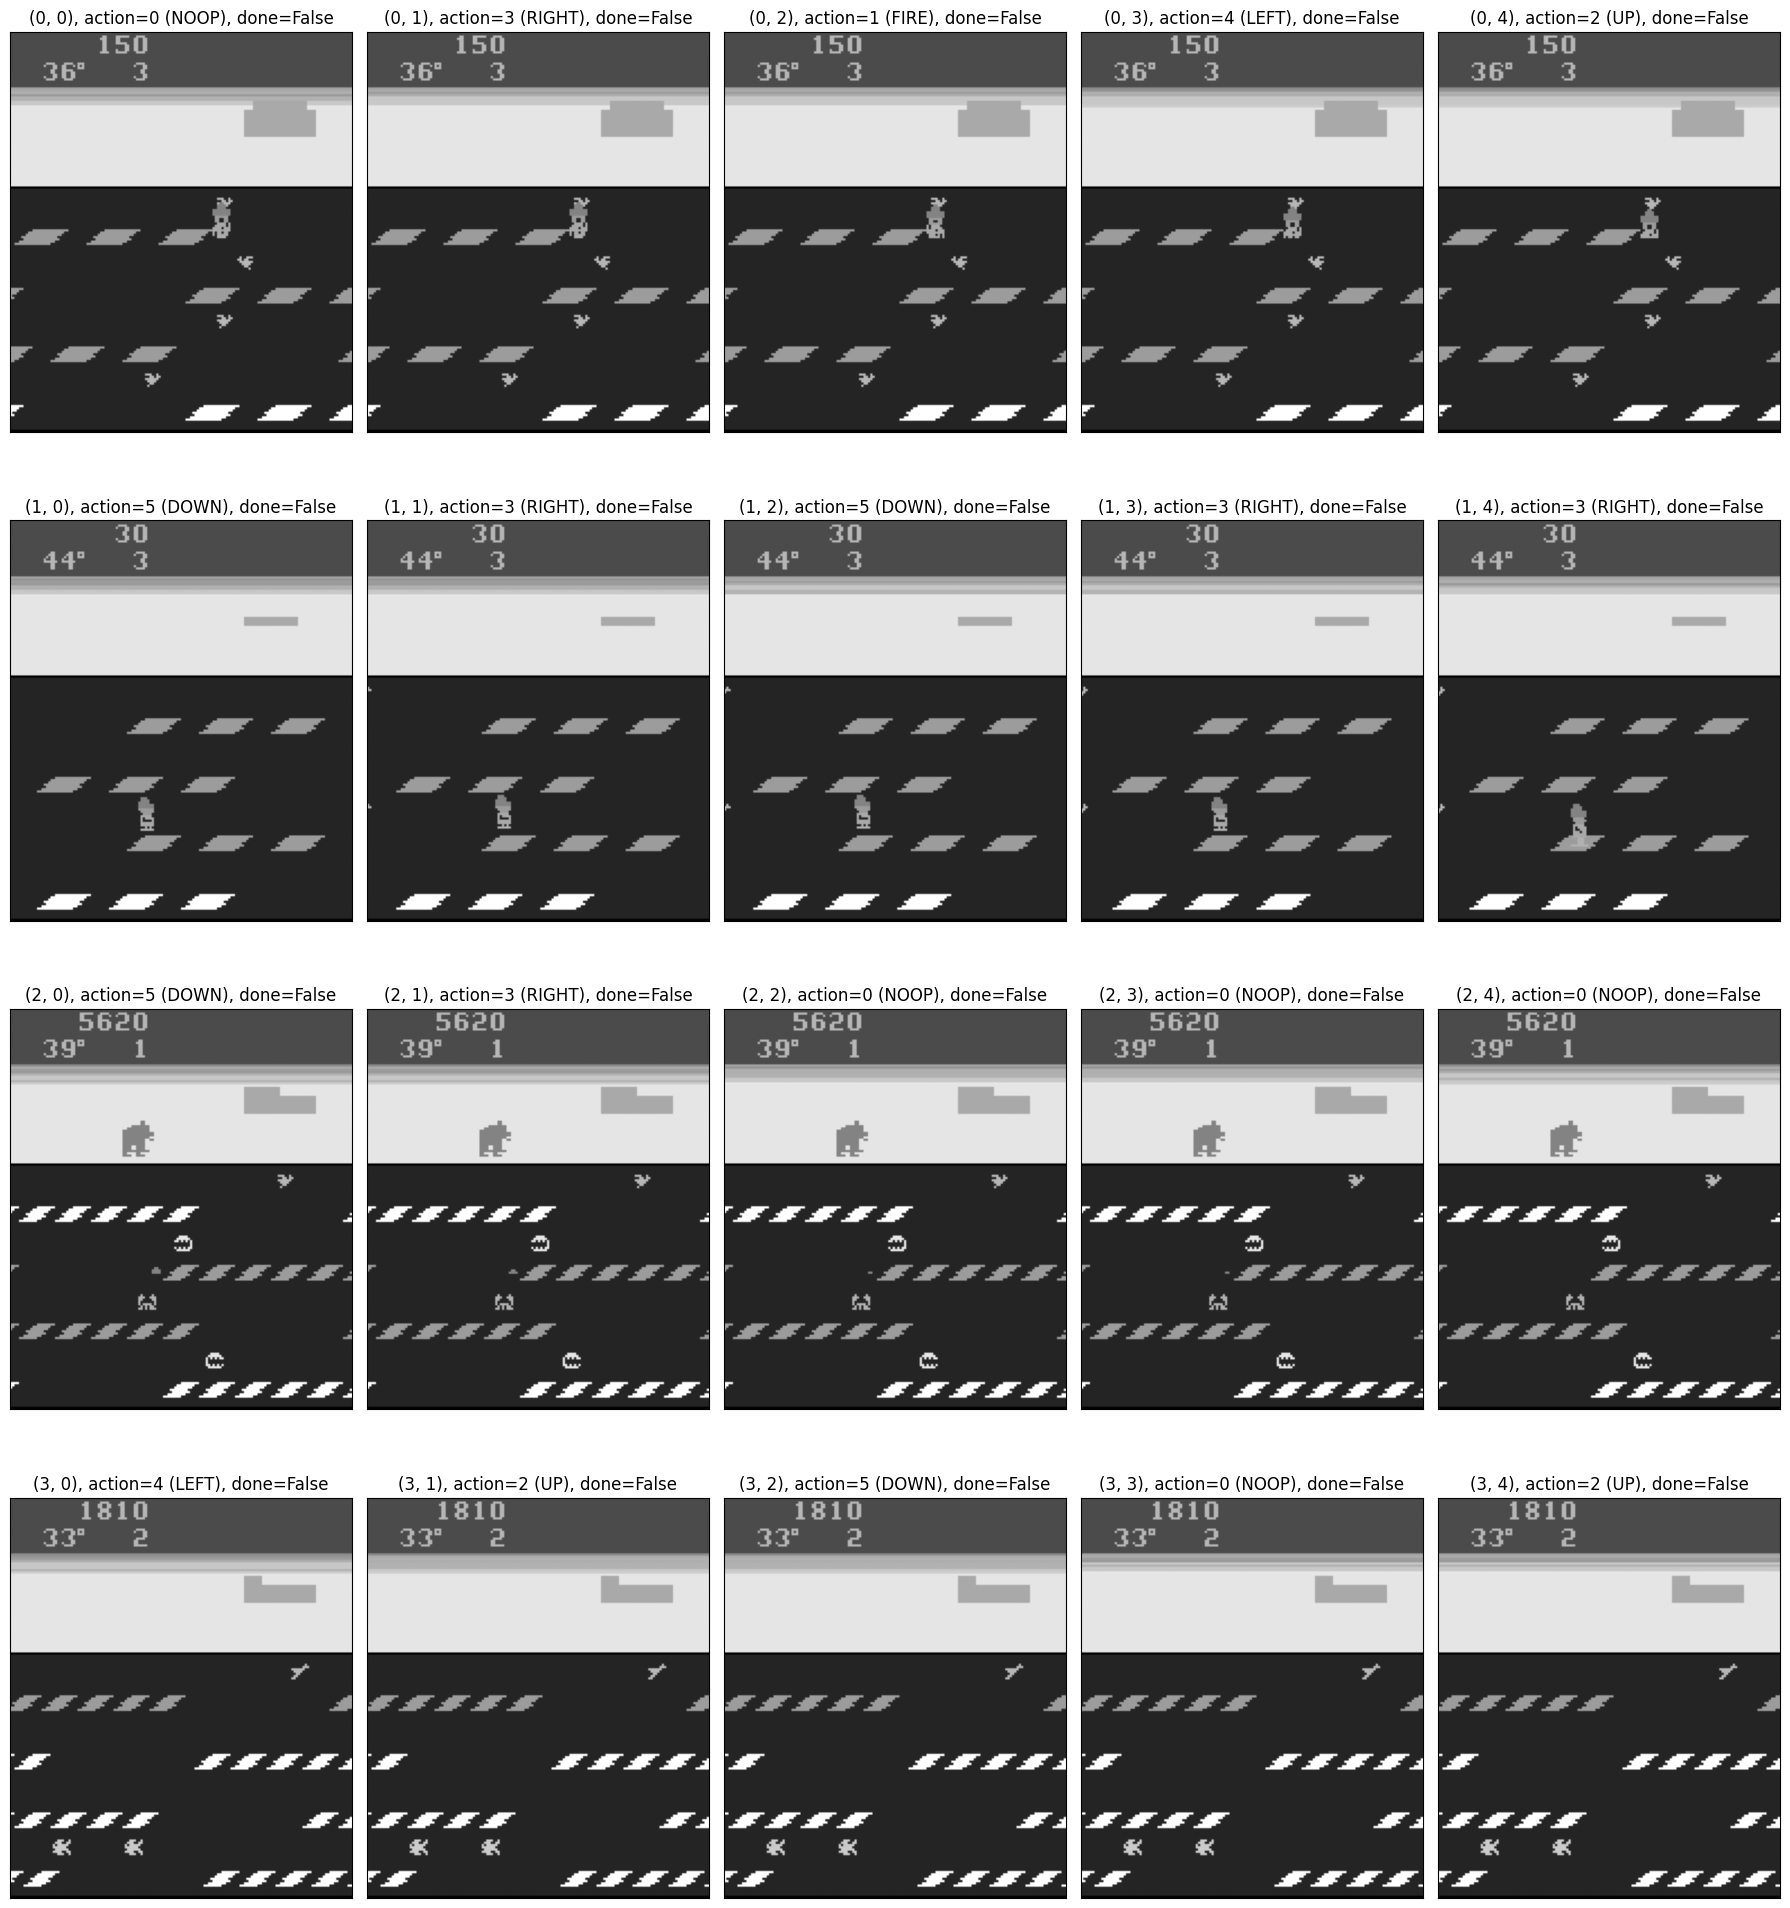

In [64]:
dataset.init_iteration(batch_size=4, is_shuffled=True)
batch = next(iter(dataset))
        
l = len(batch.obs)
s = batch.obs.shape[1]
fig, axes = plt.subplots(l, s)
if axes.ndim == 1: axes = axes[:,np.newaxis]
fig.set_figwidth(18)
fig.set_figheight(5 * len(axes))

for i, (pmasks, obs, actions, dones) in enumerate(zip(batch.pmasks, batch.obs, batch.actions, batch.dones)):
    for j, ax in enumerate(axes[i]):
        kwargs = dict(cmap='gray')
        action_name = ale_py.Action(actions[j].item()).name

        if pmasks[j] == 0:
            ax.set_title(f'{i,j}, action={actions[j]} ({action_name}), done={dones[j].bool()}')
            ax.imshow(obs[j].squeeze(0).cpu(), **kwargs)
        else:
            ax.set_title(f'{i,j}, PAD')
            ax.imshow(np.zeros(HP.dataset.ob_shape[1:]), **kwargs)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

fig.tight_layout()